# Figure 3: Incoherent Feedforward Loop (IFFL) and Robust Perfect Adaptation

**Panel A** — Equations of the IFFL model:

$$\frac{dx}{dt} = \alpha\,u - \delta\,x$$
$$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$$

In [2]:
"""Shared parameters, ODE models, simulation functions, and plotting helpers for Figure 3."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ======================================================================
# Plotting helpers
# ======================================================================

def text_panel(ax, lines, fontsize=11):
    ax.axis('off')
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', family='serif', linespacing=1.6)

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def area_above(t, y, threshold):
    """Numerical integral of (y - threshold) where y > threshold."""
    excess = np.where(y > threshold, y - threshold, 0.0)
    return np.trapz(excess, t)

# ======================================================================
# Shared parameters
# ======================================================================

PARAMS = dict(alpha=1.0, delta=1.0, beta=1.0, gamma=1.0)

def steady_state(u, p=PARAMS):
    x_ss = p['alpha'] * u / p['delta']
    y_ss = p['beta'] * p['delta'] / (p['gamma'] * p['alpha'])
    return x_ss, y_ss

# --- Panel B: single u switch ---
PANEL_B = dict(
    u_base=1.0,
    u_pert=2.0,
    t_switch=1.0,
    t_end=11.0,
)

# --- Panel C: gradual ramp u=1→0.5, then abrupt jump to u=2 ---
PANEL_C = dict(
    u_start=1.0,
    u_ramp_end=0.5,
    u_abrupt=2.0,
    t_flat=0.0,      # hold at u=1 for 1 s
    t_ramp=30.0,      # ramp duration
    t_end=40.0,      # 10 s after abrupt jump
)
PANEL_C['t_abrupt'] = PANEL_C['t_flat'] + PANEL_C['t_ramp']

# ======================================================================
# ODE right-hand side
# ======================================================================

def iffl_rhs(y_state, u, p=PARAMS):
    x, y = y_state
    dx_dt = p['alpha'] * u - p['delta'] * x
    dy_dt = p['beta'] * u - p['gamma'] * x * y
    return np.array([dx_dt, dy_dt])

# ======================================================================
# Simulation runners
# ======================================================================

def run_panel_B():
    p = PANEL_B
    x_ss, y_ss = steady_state(p['u_base'])
    x0_ss = [x_ss, y_ss]

    t1 = np.linspace(0, p['t_switch'], 250)
    sol1 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_base']).tolist(),
        [0, p['t_switch']], x0_ss, dense_output=True, max_step=0.05)
    y_switch = sol1.sol(p['t_switch'])

    t2 = np.linspace(p['t_switch'], p['t_end'], 500)
    sol2 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_pert']).tolist(),
        [p['t_switch'], p['t_end']], y_switch, dense_output=True, max_step=0.05)

    t_full = np.concatenate([t1, t2[1:]])
    x_full = np.concatenate([sol1.sol(t1)[0], sol2.sol(t2[1:])[0]])
    y_full = np.concatenate([sol1.sol(t1)[1], sol2.sol(t2[1:])[1]])
    return dict(t=t_full, x=x_full, y=y_full, t_switch=p['t_switch'],
                y_ss=y_ss,
                label_base=rf'$u={p["u_base"]}$',
                label_pert=rf'$u={p["u_pert"]}$')

def run_panel_C():
    p = PANEL_C
    x_ss, y_ss = steady_state(p['u_start'])

    # Phase 1: flat at u_start
    t1 = np.linspace(0, p['t_flat'], 100)
    sol1 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_start']).tolist(),
        [0, p['t_flat']], [x_ss, y_ss], dense_output=True, max_step=0.05)

    # Phase 2: linear ramp u from u_start → u_ramp_end
    def u_ramp(t_):
        frac = (t_ - p['t_flat']) / p['t_ramp']
        return p['u_start'] + (p['u_ramp_end'] - p['u_start']) * frac

    t2 = np.linspace(p['t_flat'], p['t_abrupt'], 400)
    sol2 = solve_ivp(
        lambda t_, y: iffl_rhs(y, u_ramp(t_)).tolist(),
        [p['t_flat'], p['t_abrupt']], sol1.sol(p['t_flat']),
        dense_output=True, max_step=0.02)

    # Phase 3: abrupt jump to u_abrupt
    t3 = np.linspace(p['t_abrupt'], p['t_end'], 500)
    sol3 = solve_ivp(
        lambda t_, y: iffl_rhs(y, p['u_abrupt']).tolist(),
        [p['t_abrupt'], p['t_end']], sol2.sol(p['t_abrupt']),
        dense_output=True, max_step=0.05)

    t_full = np.concatenate([t1, t2[1:], t3[1:]])
    y_full = np.concatenate([sol1.sol(t1)[1], sol2.sol(t2[1:])[1], sol3.sol(t3[1:])[1]])
    u_full = np.concatenate([
        np.full_like(t1, p['u_start']),
        np.array([u_ramp(t_) for t_ in t2[1:]]),
        np.full_like(t3[1:], p['u_abrupt']),
    ])
    return dict(t=t_full, y=y_full, u=u_full,
                y_ss=y_ss,
                t_flat=p['t_flat'], t_abrupt=p['t_abrupt'])

# ======================================================================
# Run all simulations
# ======================================================================
data_B = run_panel_B()
data_C = run_panel_C()

THRESHOLD = 1.2
area_B = area_above(data_B['t'], data_B['y'], THRESHOLD)
area_C = area_above(data_C['t'], data_C['y'], THRESHOLD)

print("All simulations complete.")
x_ss_base, y_ss = steady_state(PANEL_B['u_base'])
x_ss_pert, _    = steady_state(PANEL_B['u_pert'])
print(f"Panel B — base ss: x={x_ss_base:.3f}, y={y_ss:.3f}")
print(f"Panel B — pert ss: x={x_ss_pert:.3f}, y={y_ss:.3f}  (y unchanged)")
print(f"Area above threshold — B: {area_B:.3f},  C: {area_C:.3f}")

All simulations complete.
Panel B — base ss: x=1.000, y=1.000
Panel B — pert ss: x=2.000, y=1.000  (y unchanged)
Area above threshold — B: 0.091,  C: 0.349


/tmp/ipykernel_1223171/836259909.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(excess, t)


**Panel A** — IFFL model equations and steady-state analysis:

$$\frac{dx}{dt} = \alpha\,u - \delta\,x \qquad \frac{dy}{dt} = \beta\,u - \gamma\,x\,y$$

Setting both derivatives to zero:

$$x_{ss} = \frac{\alpha\,u}{\delta}, \qquad y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$$

The steady state $y_{ss}$ is **independent of $u$** — robust perfect adaptation.

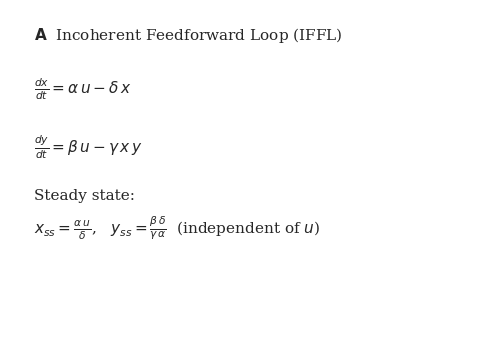

In [3]:
# Panel A: standalone equations figure
fig, ax = plt.subplots(figsize=(5, 3.5))
text_panel(ax, [
    r'$\mathbf{A}$  Incoherent Feedforward Loop (IFFL)',
    '',
    r'$\frac{dx}{dt} = \alpha\,u - \delta\,x$',
    '',
    r'$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$',
    '',
    r'Steady state:',
    r'$x_{ss} = \frac{\alpha\,u}{\delta}$,   '
    r'$y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$  (independent of $u$)',
], fontsize=11)
plt.tight_layout()
fig.savefig('figure3_panelA.pdf', bbox_inches='tight')
plt.show()

**Panel B** — Starting at steady state, changing $u$ does not affect $y_{ss}$:

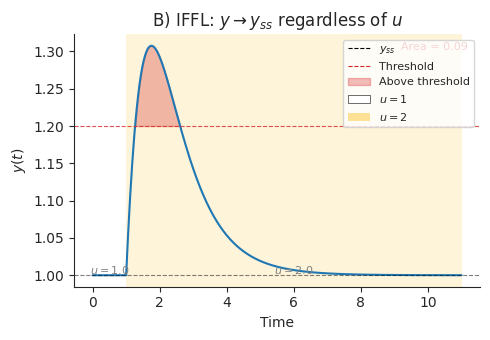

In [4]:
# Panel B: standalone plot
THRESHOLD = 1.2

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
ax.plot(data_B['t'], data_B['y'], lw=1.5, color='C0')
ax.fill_between(data_B['t'], THRESHOLD, data_B['y'],
                where=(data_B['y'] > THRESHOLD), color='C3', alpha=0.3, interpolate=True)
ax.axhline(data_B['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax.axhline(THRESHOLD, color='C3', ls='--', lw=0.8, alpha=0.8)
ax.set_ylabel('$y(t)$')
ax.set_xlabel('Time')
ax.set_title(r'B) IFFL: $y \to y_{ss}$ regardless of $u$')

ax.text(0.5, 0.05, data_B['label_base'], ha='center', fontsize=8, color='gray',
        transform=ax.get_xaxis_transform())
ax.text(6.0, 0.05, data_B['label_pert'], ha='center', fontsize=8, color='gray',
        transform=ax.get_xaxis_transform())

ax.text(0.97, 0.97, f'Area = {area_B:.2f}', transform=ax.transAxes,
        fontsize=8, ha='right', va='top', color='C3')

ax.legend(handles=[
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$y_{ss}$'),
    plt.Line2D([0],[0], color='C3',   ls='--', lw=0.8, label='Threshold'),
    mpatches.Patch(color='C3', alpha=0.3, label='Above threshold'),
    mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.4, label='$u=1$'),
    mpatches.Patch(facecolor='#fcba03', edgecolor='none', alpha=0.4, label='$u=2$'),
], fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
fig.savefig('figure3_panelB.pdf', bbox_inches='tight')
plt.show()

**Panel D** — Phase portraits of the IFFL for $u = 0.5, 1, 2$.

Nullclines: $\dot{x}=0 \Rightarrow x = u$ (vertical); $\dot{y}=0 \Rightarrow y = u/x$ (hyperbola). They intersect at $(u,\, 1)$, confirming $y_{ss}=1$ for all $u$.

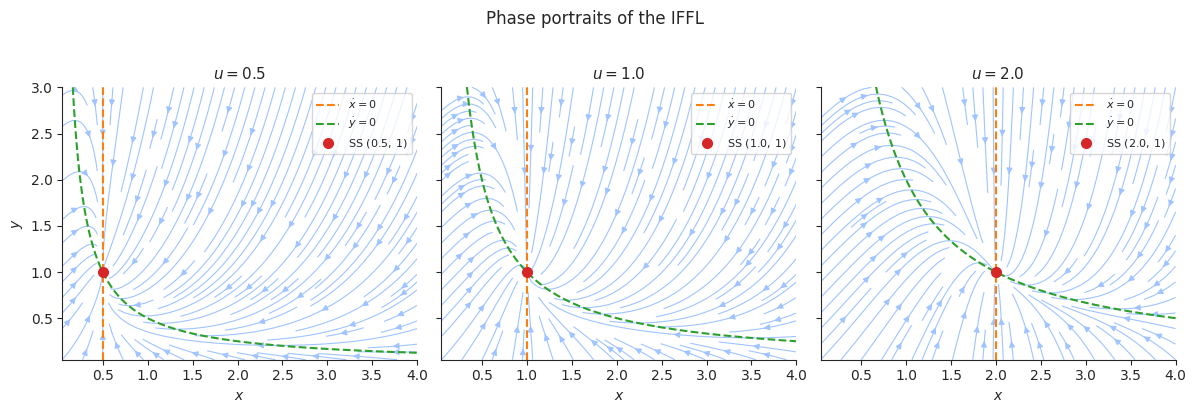

In [5]:
# Phase portraits for u = 0.5, 1, 2
U_VALS = [0.5, 1.0, 2.0]

X_LIM = (0.05, 4.0)
Y_LIM = (0.05, 3.0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

for ax, u in zip(axes, U_VALS):
    x_ss, y_ss = steady_state(u)

    x_range = np.linspace(*X_LIM, 300)
    y_range = np.linspace(*Y_LIM, 300)
    X, Y = np.meshgrid(x_range, y_range)
    DX = PARAMS['alpha'] * u - PARAMS['delta'] * X
    DY = PARAMS['beta']  * u - PARAMS['gamma'] * X * Y

    ax.streamplot(X, Y, DX, DY, density=1.2, linewidth=0.8,
                  color='#a0c4ff', arrowsize=0.9)

    ax.axvline(u, color='C1', lw=1.5, ls='--', label=r'$\dot{x}=0$')

    xnc = np.linspace(X_LIM[0], X_LIM[1], 400)
    ax.plot(xnc, u / xnc, color='C2', lw=1.5, ls='--', label=r'$\dot{y}=0$')

    ax.plot(x_ss, y_ss, 'o', color='C3', ms=7, zorder=5, label=rf'SS $({u:.1f},\,1)$')

    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.set_xlabel('$x$')
    ax.set_title(f'$u = {u}$', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    clean_ax(ax)

axes[0].set_ylabel('$y$')
fig.suptitle('Phase portraits of the IFFL', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

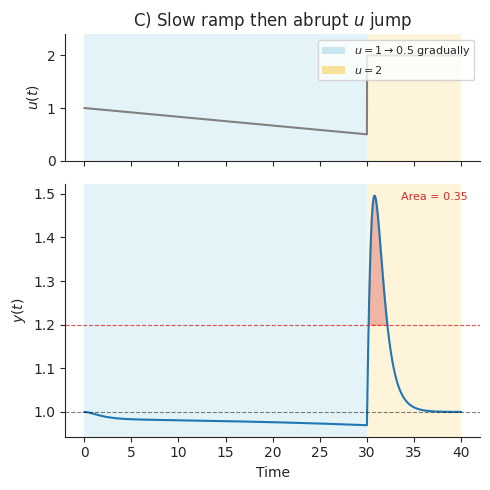

In [6]:
# Panel C: standalone plot — two subplots: u(t) on top, y(t) below
fig, (ax_u, ax_y) = plt.subplots(2, 1, figsize=(5, 5), sharex=True,
                                  gridspec_kw={'height_ratios': [1, 2]})

# Shading
ax_u.axvspan(data_C['t_flat'],   data_C['t_abrupt'], color='#a8d8ea', alpha=0.3, lw=0)
ax_u.axvspan(data_C['t_abrupt'], data_C['t'].max(),  color='#fcba03', alpha=0.15, lw=0)
ax_y.axvspan(data_C['t_flat'],   data_C['t_abrupt'], color='#a8d8ea', alpha=0.3, lw=0)
ax_y.axvspan(data_C['t_abrupt'], data_C['t'].max(),  color='#fcba03', alpha=0.15, lw=0)

# u(t)
ax_u.plot(data_C['t'], data_C['u'], lw=1.5, color='gray')
ax_u.set_ylabel('$u(t)$')
ax_u.set_ylim(0, 2.4)
clean_ax(ax_u)

# y(t)
THRESHOLD = 1.2
ax_y.plot(data_C['t'], data_C['y'], lw=1.5, color='C0')
ax_y.fill_between(data_C['t'], THRESHOLD, data_C['y'],
                  where=(data_C['y'] > THRESHOLD), color='C3', alpha=0.3, interpolate=True)
ax_y.axhline(data_C['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax_y.axhline(THRESHOLD, color='C3', ls='--', lw=0.8, alpha=0.8)
ax_y.set_ylabel('$y(t)$')
ax_y.set_xlabel('Time')
ax_y.text(0.97, 0.97, f'Area = {area_C:.2f}', transform=ax_y.transAxes,
          fontsize=8, ha='right', va='top', color='C3')
clean_ax(ax_y)

ax_u.set_title(r'C) Slow ramp then abrupt $u$ jump')
ax_u.legend(handles=[
    mpatches.Patch(facecolor='#a8d8ea', edgecolor='none', alpha=0.6, label=r'$u=1 \to 0.5$ gradually'),
    mpatches.Patch(facecolor='#fcba03', edgecolor='none', alpha=0.4, label='$u=2$'),
], fontsize=8, loc='upper right')

plt.tight_layout()
fig.savefig('figure3_panelC.pdf', bbox_inches='tight')
plt.show()

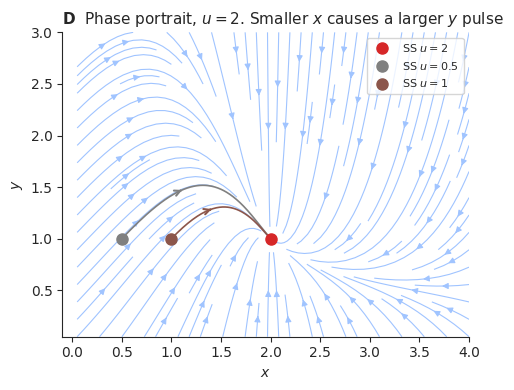

In [7]:
# Panel D: phase portrait for u=2 with trajectories starting from SS of u=0.5 and u=1
U_D = 2.0
T_END = 10.0
TRAJ_ICS    = [(0.5, 1.0), (1.0, 1.0)]
TRAJ_COLORS = ['gray', 'C5']
TRAJ_LABELS = [r'SS $u=0.5$', r'SS $u=1$']

X_LIM = (-0.1, 4.0)
Y_LIM = (0.05, 3.0)

fig, ax = plt.subplots(figsize=(5, 4))

x_range = np.linspace(0.05, X_LIM[1], 300)
y_range = np.linspace(*Y_LIM, 300)
X, Y = np.meshgrid(x_range, y_range)
DX = PARAMS['alpha'] * U_D - PARAMS['delta'] * X
DY = PARAMS['beta']  * U_D - PARAMS['gamma'] * X * Y

ax.streamplot(X, Y, DX, DY, density=1.2, linewidth=0.8,
              color='#a0c4ff', arrowsize=0.9)

# Steady state for u=2
x_ss, y_ss = steady_state(U_D)
ax.plot(x_ss, y_ss, 'o', color='C3', ms=8, zorder=6, label=r'SS $u=2$')

# Trajectories starting from SS of u=0.5 and u=1
t_eval = np.linspace(0, T_END, 500)
arrow_frac = 0.05
for (x0, y0), color, label in zip(TRAJ_ICS, TRAJ_COLORS, TRAJ_LABELS):
    sol = solve_ivp(
        lambda t_, y: iffl_rhs(y, U_D).tolist(),
        [0, T_END], [x0, y0], t_eval=t_eval, max_step=0.05)
    xs, ys = sol.y[0], sol.y[1]
    ax.plot(xs, ys, lw=1.2, color=color, zorder=5)
    ax.plot(xs[0], ys[0], 'o', color=color, ms=8, zorder=7, label=label)
    i = int(arrow_frac * len(xs))
    ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                zorder=8)

ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(r'$\mathbf{D}$  Phase portrait, $u=2$. Smaller $x$ causes a larger $y$ pulse', fontsize=11, loc='left')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()

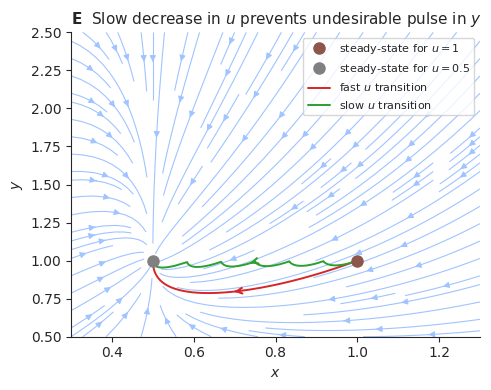

In [8]:
# Panel E: three ways to transition from u=1 → u=0.5 in phase space
T_TRANS = 30.0   # transition duration (gradual and small-jumps)
T_HOLD  = 10.0   # extra time to hold at u=0.5 after transition
T_END_E = T_TRANS + T_HOLD
N_JUMPS = 6      # number of discrete steps for the small-jumps case
X0, Y0  = 1.0, 1.0   # start = SS of u=1

X_LIM_E = (0.3, 1.3)
Y_LIM_E = (0.5, 2.5)

def simulate_transition(u_func, t_end, n_points=2000):
    t_eval = np.linspace(0, t_end, n_points)
    sol = solve_ivp(
        lambda t_, y: iffl_rhs(y, u_func(t_)).tolist(),
        [0, t_end], [X0, Y0], t_eval=t_eval, max_step=0.05)
    return sol.y[0], sol.y[1]

# 1. Instant jump
u_instant = lambda t: 0.5
xs_instant, ys_instant = simulate_transition(u_instant, T_END_E)

# 2. Small discrete jumps
u_steps = np.linspace(1.0, 0.5, N_JUMPS + 1)
dt_step = T_TRANS / N_JUMPS
def u_jumps(t):
    step = min(int(t / dt_step), N_JUMPS)
    return u_steps[step]
xs_jumps, ys_jumps = simulate_transition(u_jumps, T_END_E)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(5, 4))

# Background: phase portrait for u=0.5
x_range = np.linspace(X_LIM_E[0], X_LIM_E[1], 300)
y_range = np.linspace(Y_LIM_E[0], Y_LIM_E[1], 300)
X, Y = np.meshgrid(x_range, y_range)
U_BG = 0.5
DX = PARAMS['alpha'] * U_BG - PARAMS['delta'] * X
DY = PARAMS['beta']  * U_BG - PARAMS['gamma'] * X * Y
ax.streamplot(X, Y, DX, DY, density=1.2, linewidth=0.8, color='#a0c4ff', arrowsize=0.9, zorder=1)

# SS markers
ax.plot(1.0, 1.0, 'o', color='C5',   ms=8, zorder=6, label=r'steady-state for $u=1$')
ax.plot(0.5, 1.0, 'o', color='gray', ms=8, zorder=6, label=r'steady-state for $u=0.5$')

# Helper: draw trajectory with arrow placed at arc-length midpoint
def plot_traj(ax, xs, ys, color, label, arrow_frac=0.5):
    ax.plot(xs, ys, lw=1.4, color=color, zorder=5, label=label)
    cumlen = np.concatenate([[0], np.cumsum(np.sqrt(np.diff(xs)**2 + np.diff(ys)**2))])
    i = np.searchsorted(cumlen, arrow_frac * cumlen[-1])
    i = min(i, len(xs) - 2)
    ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5), zorder=8)

plot_traj(ax, xs_instant, ys_instant, 'C3', f'fast $u$ transition')
plot_traj(ax, xs_jumps,   ys_jumps,   'C2', f'slow $u$ transition')

ax.set_xlim(*X_LIM_E)
ax.set_ylim(*Y_LIM_E)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(r'$\mathbf{E}$  Slow decrease in $u$ prevents undesirable pulse in $y$', fontsize=11, loc='left')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1223171/836259909.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(excess, t)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


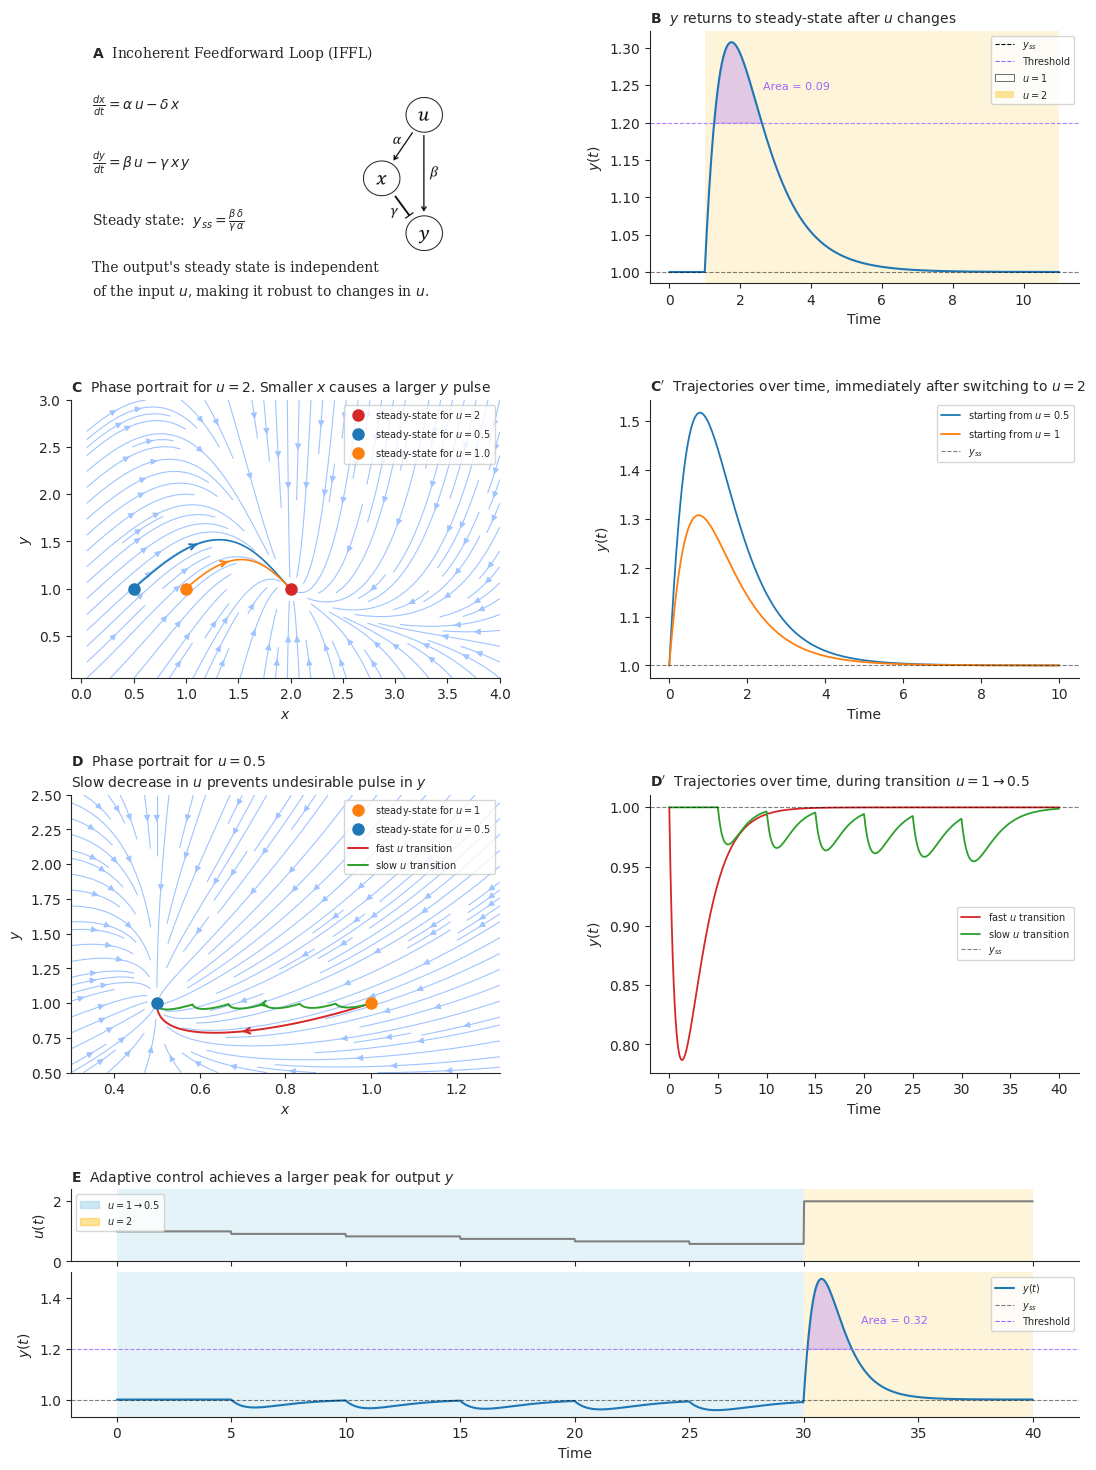

Saved figure3_composite.pdf


In [34]:
# ======================================================================
# COMPOSITE FIGURE  —  A B / C C' / D D' / E
# ======================================================================
THRESHOLD = 1.2

fig = plt.figure(figsize=(13, 18))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35,
                       height_ratios=[1, 1.1, 1.1, 0.9])

# ── Panel A: equations ────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
text_panel(ax_A, [
    r'$\mathbf{A}$  Incoherent Feedforward Loop (IFFL)',
    '',
    r'$\frac{dx}{dt} = \alpha\,u - \delta\,x$',
    '',
    r'$\frac{dy}{dt} = \beta\,u - \gamma\,x\,y$',
    '',
    r'Steady state:  $y_{ss} = \frac{\beta\,\delta}{\gamma\,\alpha}$',
    '',
    r"The output's steady state is independent",
    r"of the input $u$, making it robust to changes in $u$.",
], fontsize=10)
ax_A_img = ax_A.inset_axes([0.1, 0.13, 1.5*0.9, 0.675*0.9])
ax_A_img.imshow(plt.imread('iffl_model.png'))
ax_A_img.axis('off')

# ── Panel B: abrupt u switch ──────────────────────────────────────────
ax_B = fig.add_subplot(gs[0, 1])
ax_B.axvspan(data_B['t_switch'], data_B['t'].max(), color='#fcba03', alpha=0.15, lw=0)
ax_B.plot(data_B['t'], data_B['y'], lw=1.5, color='C0')
ax_B.fill_between(data_B['t'], THRESHOLD, data_B['y'],
                  where=(data_B['y'] > THRESHOLD), color='#9e66ff', alpha=0.3, interpolate=True)
ax_B.axhline(data_B['y_ss'], color='black', ls='--', lw=0.8, alpha=0.5)
ax_B.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax_B.set_ylabel('$y(t)$'); ax_B.set_xlabel('Time')
ax_B.set_title(r'$\mathbf{B}$  $y$ returns to steady-state after $u$ changes', fontsize=10, loc='left')
ax_B.text(0.42, 0.8, f'Area = {area_B:.2f}', transform=ax_B.transAxes,
          fontsize=8, ha='right', va='top', color='#9e66ff')
ax_B.legend(handles=[
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, label=r'$y_{ss}$'),
    plt.Line2D([0],[0], color='#9e66ff', ls='--', lw=0.8, label='Threshold'),
    mpatches.Patch(facecolor='white', edgecolor='black', linewidth=0.4, label='$u=1$'),
    mpatches.Patch(facecolor='#fcba03', edgecolor='none', alpha=0.4, label='$u=2$'),
], fontsize=7, loc='upper right')
clean_ax(ax_B)

# ── Panel C: phase portrait u=2 ───────────────────────────────────────
ax_C = fig.add_subplot(gs[1, 0])
_U_D = 2.0; _T_END = 10.0
_x_range = np.linspace(0.05, 4.0, 300); _y_range = np.linspace(0.05, 3.0, 300)
_X, _Y = np.meshgrid(_x_range, _y_range)
_DX = PARAMS['alpha'] * _U_D - PARAMS['delta'] * _X
_DY = PARAMS['beta']  * _U_D - PARAMS['gamma'] * _X * _Y
ax_C.streamplot(_X, _Y, _DX, _DY, density=1.2, linewidth=0.8, color='#a0c4ff', arrowsize=0.9)
_x_ss_C, _y_ss_C = steady_state(_U_D)
ax_C.plot(_x_ss_C, _y_ss_C, 'o', color='C3', ms=8, zorder=6, label=r'steady-state for $u=2$')
_t_eval_C = np.linspace(0, _T_END, 500)
_traj_C = []
for (_x0, _y0), _col, _lbl in zip([(0.5,1.0),(1.0,1.0)], ['C0','C1'],
                                    [r'steady-state for $u=0.5$', r'steady-state for $u=1.0$']):
    _sol = solve_ivp(lambda t_, y: iffl_rhs(y, _U_D).tolist(),
                     [0, _T_END], [_x0, _y0], t_eval=_t_eval_C, max_step=0.05)
    _xs, _ys = _sol.y[0], _sol.y[1]
    _traj_C.append((_t_eval_C, _xs, _ys, _col, _lbl))
    ax_C.plot(_xs, _ys, lw=1.2, color=_col, zorder=5)
    ax_C.plot(_xs[0], _ys[0], 'o', color=_col, ms=8, zorder=7, label=_lbl)
    _i = int(0.05 * len(_xs))
    ax_C.annotate('', xy=(_xs[_i+1], _ys[_i+1]), xytext=(_xs[_i], _ys[_i]),
                  arrowprops=dict(arrowstyle='->', color=_col, lw=1.5), zorder=8)
ax_C.set_xlim(-0.1, 4.0); ax_C.set_ylim(0.05, 3.0)
ax_C.set_xlabel('$x$'); ax_C.set_ylabel('$y$')
ax_C.set_title(r'$\mathbf{C}$  Phase portrait for $u=2$. Smaller $x$ causes a larger $y$ pulse',
               fontsize=10, loc='left')
ax_C.legend(fontsize=7, loc='upper right')
clean_ax(ax_C)

# ── C': y(t) under u=2 for the two ICs ───────────────────────────────
ax_Cty = fig.add_subplot(gs[1, 1])
_ct_labels = [r'starting from $u=0.5$', r'starting from $u=1$']
for (_t, _xs, _ys, _col, _lbl), _lbl_t in zip(_traj_C, _ct_labels):
    ax_Cty.plot(_t, _ys, color=_col, lw=1.3, label=_lbl_t)
ax_Cty.axhline(_y_ss_C, color='black', ls='--', lw=0.8, alpha=0.5, label=r'$y_{ss}$')
ax_Cty.set_ylabel('$y(t)$'); ax_Cty.set_xlabel('Time')
ax_Cty.set_title(r"$\mathbf{C'}$  Trajectories over time, immediately after switching to $u=2$", fontsize=10, loc='left')
ax_Cty.legend(fontsize=7, loc='upper right')
clean_ax(ax_Cty)

# ── Panel D: phase portrait u=0.5, fast vs slow ───────────────────────
ax_D = fig.add_subplot(gs[2, 0])
_X_LIM_E = (0.3, 1.3); _Y_LIM_E = (0.5, 2.5)
_xr = np.linspace(*_X_LIM_E, 300); _yr = np.linspace(*_Y_LIM_E, 300)
_X2, _Y2 = np.meshgrid(_xr, _yr)
_U_BG = 0.5
_DX2 = PARAMS['alpha'] * _U_BG - PARAMS['delta'] * _X2
_DY2 = PARAMS['beta']  * _U_BG - PARAMS['gamma'] * _X2 * _Y2
ax_D.streamplot(_X2, _Y2, _DX2, _DY2, density=1.2, linewidth=0.8,
                color='#a0c4ff', arrowsize=0.9, zorder=1)
ax_D.plot(1.0, 1.0, 'o', color='C1', ms=8, zorder=6, label=r'steady-state for $u=1$')
ax_D.plot(0.5, 1.0, 'o', color='C0', ms=8, zorder=6, label=r'steady-state for $u=0.5$')
_T_TRANS = 30.0; _N_JUMPS = 6; _T_END_E = _T_TRANS + 10.0
_u_steps = np.linspace(1.0, 0.5, _N_JUMPS + 1)
_dt_step = _T_TRANS / _N_JUMPS
def _u_instant(t): return 0.5
def _u_jumps(t): return _u_steps[min(int(t / _dt_step), _N_JUMPS)]
_traj_D = []
for _ufunc, _col, _lbl in [(_u_instant, 'C3', 'fast $u$ transition'),
                             (_u_jumps,   'C2', 'slow $u$ transition')]:
    _t_eval_D = np.linspace(0, _T_END_E, 2000)
    _sol2 = solve_ivp(lambda t_, y, f=_ufunc: iffl_rhs(y, f(t_)).tolist(),
                      [0, _T_END_E], [1.0, 1.0], t_eval=_t_eval_D, max_step=0.05)
    _xs2, _ys2 = _sol2.y[0], _sol2.y[1]
    _traj_D.append((_t_eval_D, _xs2, _ys2, _col, _lbl))
    ax_D.plot(_xs2, _ys2, lw=1.4, color=_col, zorder=5, label=_lbl)
    _cl = np.concatenate([[0], np.cumsum(np.sqrt(np.diff(_xs2)**2 + np.diff(_ys2)**2))])
    _ii = min(np.searchsorted(_cl, 0.5 * _cl[-1]), len(_xs2) - 2)
    ax_D.annotate('', xy=(_xs2[_ii+1], _ys2[_ii+1]), xytext=(_xs2[_ii], _ys2[_ii]),
                  arrowprops=dict(arrowstyle='->', color=_col, lw=1.5), zorder=8)
ax_D.set_xlim(*_X_LIM_E); ax_D.set_ylim(*_Y_LIM_E)
ax_D.set_xlabel('$x$'); ax_D.set_ylabel('$y$')
ax_D.set_title(
    r'$\mathbf{D}$  Phase portrait for $u=0.5$' '\n'
    r'Slow decrease in $u$ prevents undesirable pulse in $y$',
    fontsize=10, loc='left')
ax_D.legend(fontsize=7, loc='upper right')
clean_ax(ax_D)

# ── D': y(t) for fast vs slow transition ─────────────────────────────
ax_Dty = fig.add_subplot(gs[2, 1])
_x_ss_D, _y_ss_D = steady_state(0.5)
for (_t, _xs, _ys, _col, _lbl) in _traj_D:
    ax_Dty.plot(_t, _ys, color=_col, lw=1.3, label=_lbl)
ax_Dty.axhline(_y_ss_D, color='black', ls='--', lw=0.8, alpha=0.5, label=r'$y_{ss}$')
ax_Dty.set_ylabel('$y(t)$'); ax_Dty.set_xlabel('Time')
ax_Dty.set_title(r"$\mathbf{D'}$  Trajectories over time, during transition $u = 1 \to 0.5$", fontsize=10, loc='left')
ax_Dty.legend(fontsize=7, loc='center right')
clean_ax(ax_Dty)

# ── Panel E: stepped decrease then abrupt jump ────────────────────────
_E_N = 6; _E_T_RAMP = 30.0; _E_T_END = 40.0; _E_T_ABRUPT = _E_T_RAMP
_E_u_vals = np.linspace(1.0, 0.5, _E_N + 1)
_E_dt = _E_T_RAMP / _E_N
def _E_u(t):
    if t < _E_T_ABRUPT:
        return _E_u_vals[min(int(t / _E_dt), _E_N)]
    return 2.0
_x_ss0, _y_ss0 = steady_state(1.0)
_E_t_eval = np.linspace(0, _E_T_END, 2000)
_E_sol = solve_ivp(lambda t_, y: iffl_rhs(y, _E_u(t_)).tolist(),
                   [0, _E_T_END], [_x_ss0, _y_ss0], t_eval=_E_t_eval, max_step=0.05)
_E_t = _E_sol.t
_E_y = _E_sol.y[1]
_E_u_arr = np.array([_E_u(t_) for t_ in _E_t])
_E_y_ss  = _y_ss0

_E_area = area_above(_E_t, _E_y, THRESHOLD)

gs_E = gs[3, :].subgridspec(2, 1, height_ratios=[1, 2], hspace=0.1)
ax_Eu = fig.add_subplot(gs_E[0])
ax_Ey = fig.add_subplot(gs_E[1], sharex=ax_Eu)
for ax in [ax_Eu, ax_Ey]:
    ax.axvspan(0,              _E_T_ABRUPT, color='#a8d8ea', alpha=0.3, lw=0)
    ax.axvspan(_E_T_ABRUPT,    _E_T_END,    color='#fcba03', alpha=0.15, lw=0)
ax_Eu.plot(_E_t, _E_u_arr, lw=1.5, color='gray')
ax_Eu.set_ylabel('$u(t)$'); ax_Eu.set_ylim(0, 2.4)
ax_Eu.set_title(r'$\mathbf{E}$  Adaptive control achieves a larger peak for output $y$',
                fontsize=10, loc='left')
ax_Eu.legend(handles=[
    mpatches.Patch(color='#a8d8ea', alpha=0.6, label=rf'$u=1 \to 0.5$'),
    mpatches.Patch(color='#fcba03', alpha=0.4, label='$u=2$'),
], fontsize=7, loc='upper left')
clean_ax(ax_Eu)
plt.setp(ax_Eu.get_xticklabels(), visible=False)
ax_Ey.plot(_E_t, _E_y, lw=1.5, color='C0')
ax_Ey.fill_between(_E_t, THRESHOLD, _E_y,
                   where=(_E_y > THRESHOLD), color='#9e66ff', alpha=0.3, interpolate=True)
ax_Ey.axhline(_E_y_ss, color='black', ls='--', lw=0.8, alpha=0.5)
ax_Ey.axhline(THRESHOLD, color='#9e66ff', ls='--', lw=0.8, alpha=0.8)
ax_Ey.set_ylabel('$y(t)$'); ax_Ey.set_xlabel('Time')
ax_Ey.text(0.85, 0.7, f'Area = {_E_area:.2f}', transform=ax_Ey.transAxes,
           fontsize=8, ha='right', va='top', color='#9e66ff')
ax_Ey.legend(handles=[
    plt.Line2D([0],[0], color='C0', lw=1.5, label='$y(t)$'),
    plt.Line2D([0],[0], color='black', ls='--', lw=0.8, alpha=0.5, label=r'$y_{ss}$'),
    plt.Line2D([0],[0], color='#9e66ff', ls='--', lw=0.8, label='Threshold'),
], fontsize=7, loc='upper right')
clean_ax(ax_Ey)

fig.savefig('figure3_composite.pdf', bbox_inches='tight')
plt.show()
print("Saved figure3_composite.pdf")